In [56]:
# Importing all the Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import openpyxl as op # To read and write excel file
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow import keras as k
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.utils import plot_model
from keras.models import load_model

In [ ]:
# Get the Dataset or Reading the  dataset from the csv file/excel sheet

stock_data = pd.read_excel("datasets/Meta(media).xlsx")

In [58]:
# Checking the Dataset

stock_data.head()

,Date,Open,High,Low,Close,Volume
0,1999-11-18 00:00:00-05:00,27.761127,30.506736,24.405387,26.845926,62546380
1,1999-11-19 00:00:00-05:00,26.197654,26.235789,24.290985,24.634186,15234146
2,1999-11-22 00:00:00-05:00,25.206189,26.845926,24.443520,26.845926,6577870
3,1999-11-23 00:00:00-05:00,25.930725,26.617127,24.405388,24.405388,5975611
4,1999-11-24 00:00:00-05:00,24.481649,25.587518,24.405381,25.053650,4843231


In [59]:
#Displaying the structure of the dataset

stock_data.shape

(5885, 6)

In [60]:
# Check for the type of data 

stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5885 entries, 0 to 5884
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5885 non-null   object 
 1   Open    5885 non-null   float64
 2   High    5885 non-null   float64
 3   Low     5885 non-null   float64
 4   Close   5885 non-null   float64
 5   Volume  5885 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 276.0+ KB


In [61]:
#Check for the Null- Values

stock_data.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [62]:
#dropping the rows of the null values

stock_data.dropna()

#Filling the null values with 0

stock_data.fillna(0)

#Replacing the Null values with mean of the column

stock_data['Open'].fillna(value=stock_data['Open'].mean(),inplace=True)
stock_data['High'].fillna(value=stock_data['High'].mean(),inplace=True)
stock_data['Low'].fillna(value=stock_data['Low'].mean(),inplace=True)
stock_data['Close'].fillna(value=stock_data['Close'].mean(),inplace=True)
stock_data['Volume'].fillna(value=stock_data['Volume'].mean(),inplace=True)

<Axes: >

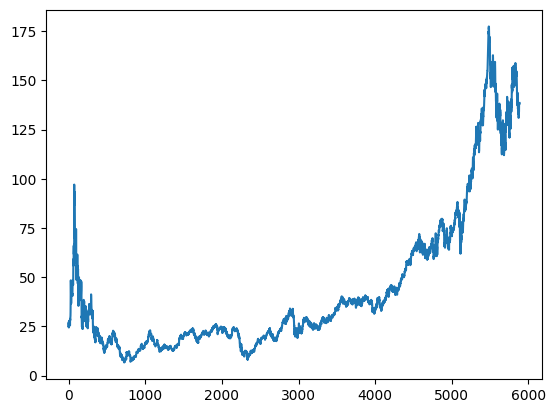

In [66]:
#plot the True Adj Close value

stock_data['Close'].plot()

In [67]:
#Set Target variable

output_var=pd.DataFrame(stock_data['Close'])

#selecting the Features

features=['Open','High','Low','Volume']

In [68]:
#Scaling

scaler=MinMaxScaler()
feature_transform = scaler.fit_transform(stock_data[features])
feature_transform= pd.DataFrame(columns=features, data=feature_transform, index=stock_data.index)
feature_transform.head()

,Open,High,Low,Volume
0,0.124287,0.138803,0.106585,1.000000
1,0.115136,0.113807,0.105907,0.240263
2,0.109332,0.117378,0.106811,0.101261
3,0.113573,0.116039,0.106585,0.091590
4,0.105091,0.110013,0.106585,0.073406


In [69]:
#Splitting to Training set and Test set

timesplit= TimeSeriesSplit(n_splits=10)
for train_index, test_index in timesplit.split(feature_transform):
    X_train, X_test = feature_transform[:len(train_index)], feature_transform[len(train_index): (len(train_index)+len(test_index))]
    y_train, y_test = output_var[:len(train_index)].values.ravel(), output_var[len(train_index): (len(train_index)+len(test_index))].values.ravel()

In [70]:
#Process the data For LSTM

trainX =np.array(X_train)
testX =np.array(X_test)
X_train = trainX.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = testX.reshape(X_test.shape[0], 1, X_test.shape[1])

In [71]:
#Building the LSTM Model

lstm = Sequential()
lstm.add(LSTM(32, input_shape=(1, trainX.shape[1]), activation='relu', return_sequences=False))
lstm.add(Dense(1))
lstm.compile(loss='mean_squared_error', optimizer='adam')
plot_model(lstm, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [72]:
# Model Training 

history=lstm.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1, shuffle=False)

Epoch 1/100
669/669 [==============================] - 2s 1ms/step - loss: 823.8587
Epoch 2/100
669/669 [==============================] - 1s 1ms/step - loss: 107.0645
Epoch 3/100
669/669 [==============================] - 1s 1ms/step - loss: 65.8117
Epoch 4/100
669/669 [==============================] - 1s 1ms/step - loss: 45.3678
Epoch 5/100
669/669 [==============================] - 1s 1ms/step - loss: 22.2881
Epoch 6/100
669/669 [==============================] - 1s 1ms/step - loss: 8.9182
Epoch 7/100
669/669 [==============================] - 1s 1ms/step - loss: 3.3411
Epoch 8/100
669/669 [==============================] - 1s 1ms/step - loss: 1.4097
Epoch 9/100
669/669 [==============================] - 1s 1ms/step - loss: 0.8064
Epoch 10/100
669/669 [==============================] - 1s 1ms/step - loss: 0.6212
Epoch 11/100
669/669 [==============================] - 1s 1ms/step - loss: 0.5615
Epoch 12/100
669/669 [==============================] - 1s 1ms/step - loss: 0.5396
Epoch 

In [73]:
lstm.save('C:\\Users\\krishna\\Downloads\\Meta(media)')
loaded_lstm = load_model('C:\\Users\\krishna\\Downloads\\Meta(media)')
loaded_y_pred = loaded_lstm.predict(X_test)

INFO:tensorflow:Assets written to: C:\Users\krishna\Downloads\Meta(media)\assets


INFO:tensorflow:Assets written to: C:\Users\krishna\Downloads\Meta(media)\assets


17/17 [==============================] - 0s 2ms/step


In [74]:
# LSTM Prediction
y_pred= lstm.predict(X_test)

17/17 [==============================] - 0s 2ms/step


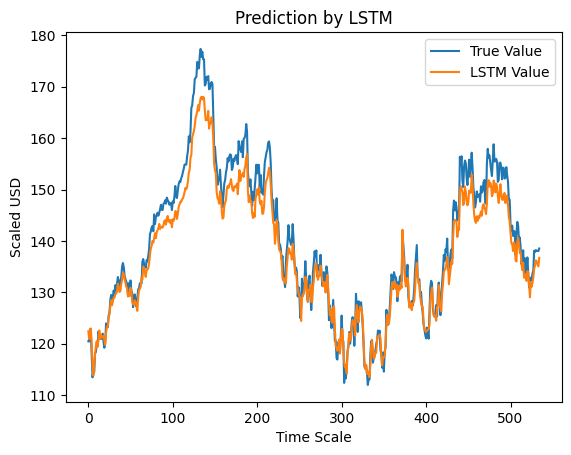

In [75]:
# Predicted vsTrue Adj Close value - LSTM

plt.plot(y_test, label='True Value')
plt.plot(y_pred, label='LSTM Value')
plt.title("Prediction by LSTM")
plt.xlabel('Time Scale')
plt.ylabel('Scaled USD')
plt.legend()
plt.show()